# Experiment: Lost Melbourne Representation and Retrieval Laboratory

**Objective:** make the main text representations concrete: tokens, a sparse TF-IDF vector, pretrained passage embeddings, cosine similarity, and an exploratory two-dimensional projection.

**Success criteria:** every example comes from the Phase 2 passage corpus; vectors have explicit dimensions; similarities use L2-normalised vectors; PCA is labelled as exploratory rather than retrieval evidence.

In [1]:
from __future__ import annotations

import json
import random
import warnings
from pathlib import Path

warnings.filterwarnings('ignore', message='IProgress not found.*')
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers.utils import logging as transformers_logging

SEED = 20260630
random.seed(SEED)
np.random.seed(SEED)

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'data' / 'processed' / 'passages.jsonl').exists())
passages = [json.loads(line) for line in (repo_root / 'data' / 'processed' / 'passages.jsonl').read_text(encoding='utf-8').splitlines()]
len(passages), repo_root

(182, PosixPath('/Users/osmanorka/Lost-Melbourne-AI-1'))

## Plan and hypotheses

1. Token IDs encode vocabulary positions, not meaning by themselves.
2. TF-IDF is high-dimensional and lexical: shared rare words drive similarity.
3. A pretrained encoder produces a fixed-size contextual passage vector.
4. Cosine similarity is measurable retrieval evidence; a 2D PCA picture is only a lossy exploratory view.

In [2]:
selected = [
    next(row for row in passages if 'Hotel Windsor' in row['text']),
    next(row for row in passages if 'Queen Victoria Market' in row['text']),
    next(row for row in passages if 'Melbourne Fish Market' in row['text']),
]
samples = [row['text'][:500] for row in selected]
[(row['passage_id'], row['section_title'], len(row['text'].split())) for row in selected]

[('pass_9cd8ef1c7830bdfd',
  '1880–1893: "Marvellous Melbourne" Land Boom era',
  439),
 ('pass_f9d3e777eb3e3f3e', 'Overview', 433),
 ('pass_c6c02e8d2b683d6e',
  '1880–1893: "Marvellous Melbourne" Land Boom era',
  439)]

## Token IDs and TF-IDF

The pretrained model tokenizer maps text fragments to integer IDs. Those integers are lookup keys. TF-IDF instead creates one sparse document-level coordinate per vocabulary term/ngram and weights corpus-specific rarity.

In [3]:
MODEL = 'sentence-transformers/all-MiniLM-L6-v2'
REVISION = '1110a243fdf4706b3f48f1d95db1a4f5529b4d41'
transformers_logging.disable_progress_bar()
model = SentenceTransformer(MODEL, revision=REVISION)
tokenised = model.tokenizer(samples[0], truncation=True, max_length=64)
token_demo = {
    'tokens': model.tokenizer.convert_ids_to_tokens(tokenised['input_ids'][:20]),
    'token_ids': tokenised['input_ids'][:20],
}
token_demo

{'tokens': ['[CLS]',
  '(',
  '1884',
  '–',
  '1885',
  ')',
  ',',
  'middle',
  'park',
  'primary',
  '(',
  '1887',
  ')',
  ',',
  'ya',
  '##rra',
  'primary',
  'school',
  'in',
  'richmond'],
 'token_ids': [101,
  1006,
  6988,
  1516,
  6571,
  1007,
  1010,
  2690,
  2380,
  3078,
  1006,
  6837,
  1007,
  1010,
  8038,
  11335,
  3078,
  2082,
  1999,
  6713]}

In [4]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), stop_words='english')
tfidf_matrix = tfidf.fit_transform(samples)
first = tfidf_matrix.getrow(0)
top_positions = first.indices[np.argsort(first.data)[-10:][::-1]]
tfidf_demo = {
    'shape': tfidf_matrix.shape,
    'nonzero_first_passage': int(first.nnz),
    'top_terms': tfidf.get_feature_names_out()[top_positions].tolist(),
}
tfidf_demo

{'shape': (3, 243),
 'nonzero_first_passage': 87,
 'top_terms': ['primary',
  '1885',
  'primary school',
  'school',
  '1888',
  'university',
  'melbourne',
  'building',
  '1886',
  'college']}

## Dense passage embeddings and cosine similarity

The encoder combines contextual token representations and pools them into one 384-dimensional passage embedding. Normalisation makes the matrix dot product equal cosine similarity.

In [5]:
dense = np.asarray(model.encode(samples, normalize_embeddings=True, show_progress_bar=False))
cosine = dense @ dense.T
{
    'embedding_shape': dense.shape,
    'vector_norms': np.linalg.norm(dense, axis=1).round(6).tolist(),
    'cosine_similarity': cosine.round(3).tolist(),
}

{'embedding_shape': (3, 384),
 'vector_norms': [1.0, 1.0, 1.0],
 'cosine_similarity': [[1.0, 0.25200000405311584, 0.4560000002384186],
  [0.25200000405311584, 1.0, 0.4699999988079071],
  [0.4560000002384186, 0.4699999988079071, 1.0]]}

## Exploratory PCA projection

PCA compresses 384 dimensions to two while preserving as much global variance as it can. Distances in this chart are not proof of semantic or retrieval quality; the held-out retrieval metrics are the relevant test.

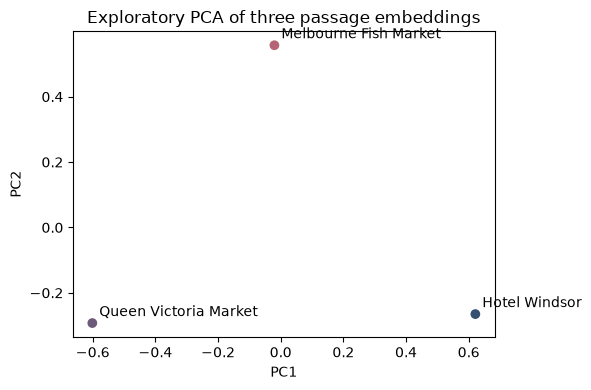

In [6]:
projection = PCA(n_components=2, random_state=SEED).fit_transform(dense)
labels = ['Hotel Windsor', 'Queen Victoria Market', 'Melbourne Fish Market']
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(projection[:, 0], projection[:, 1], color=['#355070', '#6d597a', '#b56576'])
for label, (x, y) in zip(labels, projection):
    ax.annotate(label, (x, y), xytext=(5, 5), textcoords='offset points')
ax.set(title='Exploratory PCA of three passage embeddings', xlabel='PC1', ylabel='PC2')
fig.tight_layout()
plt.show()

## Representation distinctions

- **Token IDs:** integer vocabulary keys; they carry no geometric meaning by themselves.
- **Token embeddings:** learned vectors looked up for token IDs.
- **Contextual embeddings:** token vectors after attention has incorporated surrounding text.
- **Document/passage embeddings:** one pooled vector intended to represent an entire text span.
- **Future tiny Transformer embedding matrix:** a from-scratch table learned during the later language-model phase; it is not trained or evaluated here.

**Decision:** use benchmark metrics rather than the PCA plot to choose retrieval. Keep TF-IDF as a strong transparent default while retaining dense and hybrid traces for semantic and structured cases.